# Session 2.5 — Part A: 1D Convolutions for Audio

---

## The Core Question: Why 1D?

When you learned image processing, convolutions slide a filter across **two dimensions** — height and width. A 3×3 kernel moves right, then down, then right again.

Audio is different. A raw audio file is just a **list of numbers** — pressure samples measured thousands of times per second. At 16kHz, your 3-second clip is literally:

```
[0.002, -0.001, 0.008, 0.003, -0.005, ... ]  ← 48,000 numbers
```

There is no "height." There is only **time**. So we convolve in **one dimension only** — sliding left to right across time.

---

## What is a Convolution, Really?

Forget the math for a second. Think of it this way:

Imagine you're reading a long book, and you have a **magnifying lens** that covers exactly 5 words at a time. You place the lens at position 1 (words 1–5), look at them together, and write down one observation. Then you slide the lens one word to the right (words 2–6), and write another observation. You keep sliding until you've read the whole book.

That lens is your **kernel** (also called a filter). The "observation" you write down is a **weighted sum** — the kernel has learned numbers that activate strongly when a certain pattern appears under it.

For audio, instead of words, the lens covers **samples**. A kernel of size 5 looks at 5 consecutive audio samples at a time.

---

## Anatomy of a 1D Convolution

Let's build intuition for each component:

### Kernel Size
How wide is your "lens"? 
- Kernel size 3 → looks at 3 samples at once (~0.2ms at 16kHz)
- Kernel size 400 → looks at 400 samples at once (~25ms — roughly one "frame" of speech)

Small kernels catch **fine-grained** patterns (a single click, a zero-crossing). Large kernels catch **coarser** patterns (a vowel, a pitch period).

### Stride
After each observation, how far do you **slide** the lens?
- Stride 1 → move 1 sample to the right (dense, overlapping)
- Stride 4 → move 4 samples (you skip 3, output is 4× smaller)

Stride compresses time. Conv-TasNet uses large strides in its encoder to reduce computation.

### Output Size Formula
Given input length `L`, kernel size `K`, stride `S`:

```
output_length = floor((L - K) / S) + 1
```

Try it: L=48000, K=5, S=1 → output = 47,996 samples. Makes sense — you lose a few samples at the edges.

### Padding
What happens at the boundaries? When your kernel is at position 0, it needs samples at positions -2, -1 to center itself. Those don't exist.

Two common solutions:
- **"valid" padding:** Don't go to the boundaries. Output is smaller than input.
- **"same" padding:** Pad the input with zeros on both sides so output length = input length.
- **Causal padding:** Pad only on the **left** (past), never on the right (future). Critical for real-time systems that can't look ahead in time.

### Channels
A single kernel learns one pattern. But you want to detect **many** patterns simultaneously — pitch, silence, consonants, noise. So you use multiple kernels in parallel.

If you have 8 kernels, your output has 8 **channels** — one per pattern detected. This is exactly like RGB images having 3 channels, but here each channel represents a different learned audio feature.

---

## What Does a Kernel Actually Learn?

A kernel is just a small array of trainable weights, e.g.:

```
kernel = [0.1, 0.5, -0.3, 0.5, 0.1]   # size 5
```

At each position, you multiply element-wise with the 5 samples underneath, then sum everything up. That's your output for this position.

- A kernel with weights `[1, -1]` → detects **sudden changes** (edges in time)
- A kernel with weights `[1, 1, 1, 1, 1]` → detects **average energy** (smooth regions)
- After training, kernels learn to detect speech-relevant patterns automatically

---

## The Tensor Shape Convention

PyTorch uses: `(batch, channels, time)`

```
(32, 1, 48000)  →  batch of 32, mono audio (1 channel), 48000 samples
(32, 8, 47996)  →  after conv with 8 filters, kernel=5, stride=1
```

This is different from images which are `(batch, channels, height, width)`. Audio just drops the height dimension.

---

## Why This Matters for EEND

Your eventual system needs to:
1. **Encode** raw audio into a compressed representation (encoder: Conv1D with large stride)
2. **Process** that representation with many stacked convolutions to understand who is speaking
3. **Decode** back to audio or speaker masks (transposed conv or upsampling)

Every single one of those steps is 1D convolution over the time axis. Understanding this deeply is understanding Conv-TasNet's skeleton.

---

## TODOs

I've designed **three TODOs** here. The first two build understanding from scratch. The third connects it to your real audio data.

---

### TODO 1: Manual 1D Convolution (No PyTorch Conv Layers)

**Goal:** Implement convolution yourself using only basic tensor operations, so you truly understand the sliding window.

**Requirements:**
- Write a function `my_conv1d(signal, kernel, stride=1)` 
- `signal` shape: `(time,)` — a single 1D signal, no batch or channels yet
- `kernel` shape: `(kernel_size,)` — a single filter
- Returns output of shape `(output_length,)` where you compute the formula yourself
- At each position: multiply the window by the kernel element-wise, then sum
- Use a Python loop to slide — don't use `torch.nn.Conv1d` or `F.conv1d`

**Hints:**
- You'll need a loop that goes from position `0` to `output_length`
- At each step `i`, your window is `signal[i*stride : i*stride + kernel_size]`
- `torch.dot()` can do the element-wise multiply + sum in one shot
- Compute `output_length` with the formula before allocating output tensor

**Test it with:**
- A sine wave signal of length 100
- A kernel like `[1.0, -1.0]` (edge detector) — what do you expect this to output on a smooth sine?
- A kernel of all ones divided by kernel_size (moving average) — what should this do to a noisy signal?

**Expected output:** A shorter tensor of numbers. Visually, the edge detector should produce something that oscillates (the derivative of sine is cosine).

---

### TODO 2: Add Batches, Channels, and Padding — Match PyTorch's Conv1d

**Goal:** Extend your manual conv to handle the full `(batch, in_channels, time)` format, then verify it matches `torch.nn.Conv1d` exactly.

**Requirements:**
- Extend your function to `my_conv1d_full(x, weight, stride=1, padding=0)`
- `x` shape: `(batch, in_channels, time)`
- `weight` shape: `(out_channels, in_channels, kernel_size)`
- Implement `padding` by manually concatenating zeros to both sides of the time dimension before convolving — use `torch.nn.functional.pad` or `torch.cat`
- For each output channel, sum across all input channels (this is how multi-channel conv works)
- Return shape: `(batch, out_channels, output_time)`
- **Verification step:** Create a `torch.nn.Conv1d` layer, copy its `.weight` tensor into your function, run both on the same input, and assert the outputs match within 1e-5

**Hints:**
- You'll need nested loops: over `batch`, over `out_channels`, over `in_channels`, over time positions
- The inner operation is still a dot product, just across a 2D window now (`in_channels × kernel_size`)
- `torch.allclose(a, b, atol=1e-5)` is your friend for verification
- Start with batch=1, in_channels=1, out_channels=1 before going multi-channel

**After it works — Experiments:**
- Try stride=1 vs stride=4: how does output length change? Does the formula hold?
- Try padding=0 vs padding=kernel_size//2: does "same" padding restore the original length?
- Time your loop vs PyTorch's version: `import time` and measure both on a (1, 1, 48000) signal. How much faster is PyTorch?

---

### TODO 3: Apply Real Conv1d to Your Audio Data

**Goal:** Use `torch.nn.Conv1d` on your actual audio files and visualize what the filters respond to.

**Requirements:**
- Load one `.wav` file from your dataset using `torchaudio.load()` — output shape will be `(channels, samples)`, add a batch dim to make it `(1, 1, 48000)`
- Create a `torch.nn.Conv1d(in_channels=1, out_channels=8, kernel_size=400, stride=160)` — this mimics a real speech encoder (25ms window, 10ms hop)
- Run your audio through it — print the output shape and confirm it matches your formula
- After training this layer for a few gradient steps on a dummy task (e.g., predict `torch.randn(1, 3)` from the mean of the output), print the 8 learned kernels and plot them using matplotlib

**Hints:**
- `torchaudio.load()` returns `(waveform, sample_rate)` — make sure sample rate is 16000
- You don't need to train seriously — just do 50 steps of random gradient descent so the weights move away from initialization
- To plot kernel `i`, access `layer.weight[i, 0, :]` — that's a 1D array of 400 numbers
- Use `plt.subplot(4, 2, i+1)` to make a grid of 8 plots

**Key question to answer after:** Do all 8 kernels look different? If you initialize them randomly, they should specialize into different patterns after even a few gradient steps. What shapes do you see?

---

Take TODO 1 first. Come back with your code and what you observe on the sine wave + edge detector experiment. Don't worry about it being perfect — let's see how you think through the sliding window.

In [20]:
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
import math
from pathlib import Path
import os
import sys
import json
import matplotlib.pyplot as plt

# Check if __file__ exists (it won't in Jupyter)
try:
    current_dir = Path(__file__).parent
except NameError:
    # If in Jupyter, use the current working directory
    current_dir = Path(os.getcwd())

# Add project root to Python path
project_root = current_dir.parent.parent.parent
sys.path.insert(0, str(project_root))

from src.preprocessing.audio_utils import load_audio


# Device configuration (for your MacBook)
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print("✅ Using Apple Silicon GPU")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print("✅ Using NVIDIA GPU")
else:
    device = torch.device('cpu')
    print("⚠️ Using CPU")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")


✅ Using Apple Silicon GPU
PyTorch version: 2.10.0
Device: mps


In [2]:
class SpeakerDataset(torch.utils.data.Dataset):
    def __init__(self, manifest_path, limit=None):
        # Load manifest JSON
        # Store all entries as self.data
        with open(manifest_path, "r") as f:
            full_data = json.load(f)
        
        if limit:
            self.data = full_data[:limit]
        else:
            self.data = full_data
    
    def __len__(self):
        # Return number of samples
        return len(self.data)
    
    def __getitem__(self, idx):
        # Get entry at index idx
        # Load audio from disk
        # Extract features
        # Get label (num_speakers - 1)
        # Return (features, label)
        entry = self.data[idx]
        mixture_path = Path(entry['mixture_path'])
        mixture_audio, _ = load_audio(mixture_path)
        mixture_tensor = torch.from_numpy(mixture_audio)
        
        max_len = 48000
        
        if mixture_tensor.size(0) > max_len:
            # Truncate if too long
            mixture_tensor = mixture_tensor[:max_len]
        else:
            # Pad with zeros if too short
            padding = max_len - mixture_tensor.size(0)
            mixture_tensor = torch.nn.functional.pad(mixture_tensor, (0, padding))
        
        mixture_tensor = mixture_tensor.unsqueeze(0)
        
        speaker_count = int(entry['num_speakers']) - 1
        label_tensor = torch.tensor(speaker_count, dtype=torch.long)
        
        return mixture_tensor, label_tensor

In [3]:
train_manifest_path = Path.cwd().parent.parent.parent / "data" / "processed" / "train" / "train_manifest.json"
train_dataset = SpeakerDataset(train_manifest_path)
print(len(train_dataset))

val_manifest_path = Path.cwd().parent.parent.parent / "data" / "processed" / "val" / "val_manifest.json"
val_dataset = SpeakerDataset(val_manifest_path, 2000)
print(len(val_dataset))

10000
2000


In [4]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    drop_last=False
)

### todo 1

In [5]:
def my_conv1d(signal, kernel, stride=1):
    """
    Performs a manual 1D cross-correlation convolution by sliding a kernel across a 
    signal and computing the sum of element-wise products at each step.

    Args:
        signal (torch.Tensor): The input sequence to be processed; shape (time,).
        kernel (torch.Tensor): The filter weights used to extract features; shape (kernel_size,).
        stride (int): The number of steps the window moves between each operation; default is 1.

    Returns:
        torch.Tensor: The resulting feature map; shape (L_out,), where 
                      L_out = floor((time - kernel_size) / stride) + 1.
    """
    kernel_size = len(kernel)
    output_length = math.floor(((len(signal) - kernel_size) / stride) + 1)
    output = torch.zeros(output_length)
    
    for i in range(output_length):
        output[i] = torch.sum(kernel * signal[i * stride : (i * stride) + kernel_size])
    
    return output

In [6]:
signal = train_dataset[0][0][0]

kernel = torch.randn(4)

print(len(my_conv1d(signal, kernel, 2)))
print(len(my_conv1d(signal, kernel, 4)))


23999
12000


In [7]:
signal = train_dataset[0][0][0]

kernel = torch.randn(200)

print(len(my_conv1d(signal, kernel, 2)))
print(len(my_conv1d(signal, kernel, 4)))


23901
11951


In [8]:
signal = train_dataset[0][0][0]

kernel = torch.randn(400)

print(len(my_conv1d(signal, kernel, 2)))
print(len(my_conv1d(signal, kernel, 4)))


23801
11901


### todo 2

In [9]:
def my_conv1d_full(x, weight, stride=1, padding=0):
    """
    Performs a multi-channel 1D convolution with batch processing and padding, 
    matching the functional behavior of torch.nn.Conv1d.

    Args:
        x (torch.Tensor): Input batch of signals; shape (batch, in_channels, time).
        weight (torch.Tensor): Trainable filter weights; shape (out_channels, in_channels, kernel_size).
        stride (int): The distance between adjacent window applications; default is 1.
        padding (int): Number of zero-padding elements added to both sides of the input; default is 0.

    Returns:
        torch.Tensor: The convolved feature map; shape (batch, out_channels, output_time), 
                      where output_time = floor((time + 2*padding - kernel_size) / stride) + 1.
    """
    if padding != 0:
        pad = (padding, padding)
        x = torch.nn.functional.pad(x, pad)
    
    kernel_size = len(weight[0][0])
    
    batchs = len(x)
    out_channels = len(weight)
    in_channels = len(x[0])
    output_time = math.floor(((len(x[0][0]) - kernel_size) / stride) + 1)
    output = torch.zeros((batchs, out_channels, output_time))
    
    for b in range(batchs):
        for i in range(out_channels):
            for j in range(in_channels):
                for k in range(output_time):
                    output[b][i][k] = torch.sum(weight[i][j] * x[b][j][k * stride : (k * stride) + kernel_size])
    
    return output


# use `.detach().clone()` with `conve.weight` to prevent crashing 

Now the root cause of your original crash is clear: `conv.weight` is a live parameter tensor **with gradient tracking**. Passing it into **4 nested loops** with hundreds of slice operations **builds a massive computation graph** that **kills memory**. The **fix** is always **.detach()** when you just need the numbers.


In [10]:
with torch.no_grad():
    x = train_dataset[0][0].view(1, 1,-1)
    conv = nn.Conv1d(1, 5, 400, stride=5, padding=4, bias=False)
    weights = conv.weight.detach().clone()
    a = my_conv1d_full(x, weights, stride=5, padding=4)
    b = conv(x)
    print(torch.allclose(a, b, atol=1e-5))

True


In [11]:
with torch.no_grad():
    x = torch.randn(2, 1, 1000)
    conv = nn.Conv1d(1, 5, 400, stride=160, padding=4, bias=False)
    weights = conv.weight.detach().clone() 
    a = my_conv1d_full(x, weights, stride=160, padding=4)
    b = conv(x)
    print(torch.allclose(a, b, atol=1e-5))

True


### todo 3

In [12]:
class EarlyStopping:
    def __init__(self, patience, min_delta):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float("inf")
        self.should_stop = False
    
    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.counter = 0
            self.best_loss = val_loss
            self.should_stop = False # improvement 
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
            else: 
                self.should_stop = False
        
        return self.should_stop

In [13]:
def compute_accuracy(predictions, labels):
    """
    predictions: (batch_size, 3) logits
    labels: (batch_size,) true classes
    
    Returns: accuracy as percentage
    """
    predicted_classes = torch.argmax(predictions, dim=1)
    correct = (predicted_classes == labels).sum().item()
    total = labels.size(0)
    return 100.0 * correct / total

In [14]:
class SpeakerCounter(nn.Module):
    """
    Classifier that predicts number of speakers (1, 2, or 3)
    from audio features.
    """
    def __init__(self,out_channels=8, num_classes=3):
        super().__init__()
        # TODO: Build network with given architecture
        # Hint: Use nn.Sequential or define layers individually
        
        self.conv = nn.Conv1d(in_channels=1, out_channels=out_channels, kernel_size=400, stride=160)
        self.fc = nn.Linear(out_channels, num_classes)
        
    def forward(self, x):
        # TODO: Implement forward pass
        x = self.conv(x)
        x = torch.mean(x, dim=2)
        x = self.fc(x)
        return x

In [17]:
def train_with_optimizer(optimizer_name="sgd", num_epochs=5):
    
    model = SpeakerCounter().to(device)
    
    if optimizer_name=="sgd":
        optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)
    elif optimizer_name=="adam":
        optimizer = optim.Adam(model.parameters(), lr=0.0001)
    elif optimizer_name=="adamw":
        optimizer = optim.AdamW(model.parameters(), lr=0.0001)
    
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5, min_lr=1e-6)
    early_stop = EarlyStopping(patience=5, min_delta=0.001)
    
    output = {
        'train_losses': [], 
        'val_losses': [], 
        'train_accs': [], 
        'val_accs': []
    }
    
    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        running_train_acc = 0.0
        steps_per_epoch_train = len(train_loader)
        
        for step, batch in enumerate(train_loader):
            features, labels = batch[0].to(device), batch[1].to(device)
            
            # Forward pass
            logits = model(features)  
            
            # Compute loss
            loss = F.cross_entropy(logits, labels)
            
            # Backward pass
            loss.backward()
            
            # Update weights
            optimizer.step()
            optimizer.zero_grad()
            
            # Compute accuracy
            running_train_loss += loss.item() 
            running_train_acc += compute_accuracy(logits, labels)
            
            # Optional: Print batch progress every 50 batches within the epoch
            if (step + 1) % 50 == 0:
                print(f"  train Batch {step+1}/{steps_per_epoch_train} | Loss: {loss.item():.4f}")
        
        # 3. Print Summary at the end of each FULL epoch
        avg_train_loss = running_train_loss / steps_per_epoch_train
        avg_train_acc = running_train_acc / steps_per_epoch_train    
        
        model.eval()
        running_val_loss = 0.0
        running_val_acc = 0.0     
        steps_per_epoch_val = len(val_loader)
        
        with torch.no_grad():
            for steps, batch in enumerate(val_loader):
                
                features, labels = batch[0].to(device), batch[1].to(device)
                
                # Forward pass
                logits = model(features)  
                
                # Compute loss
                loss = F.cross_entropy(logits, labels)
                
                # number of correct class
                running_val_loss += loss.item()
                running_val_acc += compute_accuracy(logits, labels)
                
                # Optional: Print batch progress every 50 batches within the epoch
                if (steps + 1) % 30 == 0:
                    print(f"  val Batch {steps+1}/{steps_per_epoch_val} | Loss: {loss.item():.4f}")
        
        # Calculate Averages
        avg_val_loss = running_val_loss / steps_per_epoch_val
        avg_val_acc = running_val_acc / steps_per_epoch_val   
        
        # --- LOGGING & SCHEDULER ---
        print(f"\n--- Epoch {epoch+1}/{num_epochs} Summary ---")
        print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}%")
        print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {avg_val_acc:.2f}%")
        
        scheduler.step(avg_val_loss)
        
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Current Learning Rate: {current_lr}\n")
        
        output['train_losses'].append(avg_train_loss)
        output['val_losses'].append(avg_val_loss)
        output['train_accs'].append(avg_train_acc)
        output['val_accs'].append(avg_val_acc)
        
        if early_stop(avg_val_loss):
            print("Early stopping triggered")
            print(f"triggered at epoch: {epoch}")
            print(f"best val loss achieved: {early_stop.best_loss:.6f}")
            break
    
    return output, model



In [18]:
output, model = train_with_optimizer("adamw", 100)

  train Batch 50/312 | Loss: 0.9919
  train Batch 100/312 | Loss: 0.9705
  train Batch 150/312 | Loss: 0.9920
  train Batch 200/312 | Loss: 0.9872
  train Batch 250/312 | Loss: 0.9999
  train Batch 300/312 | Loss: 0.9860
  val Batch 30/63 | Loss: 0.9114
  val Batch 60/63 | Loss: 0.9525

--- Epoch 1/100 Summary ---
Train Loss: 0.9736 | Train Acc: 50.23%
Val Loss:   0.9626 | Val Acc:   49.26%
Current Learning Rate: 0.0001

  train Batch 50/312 | Loss: 0.9152
  train Batch 100/312 | Loss: 0.9975
  train Batch 150/312 | Loss: 0.9456
  train Batch 200/312 | Loss: 0.9625
  train Batch 250/312 | Loss: 0.9576
  train Batch 300/312 | Loss: 0.9071
  val Batch 30/63 | Loss: 0.8842
  val Batch 60/63 | Loss: 0.9202

--- Epoch 2/100 Summary ---
Train Loss: 0.9438 | Train Acc: 50.23%
Val Loss:   0.9290 | Val Acc:   49.26%
Current Learning Rate: 0.0001

  train Batch 50/312 | Loss: 0.9132
  train Batch 100/312 | Loss: 0.9508
  train Batch 150/312 | Loss: 0.8964
  train Batch 200/312 | Loss: 0.9113
  t

/var/folders/xv/_4w930m56tbd6cr6d1lpb7r80000gn/T/ipykernel_39689/3290836059.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


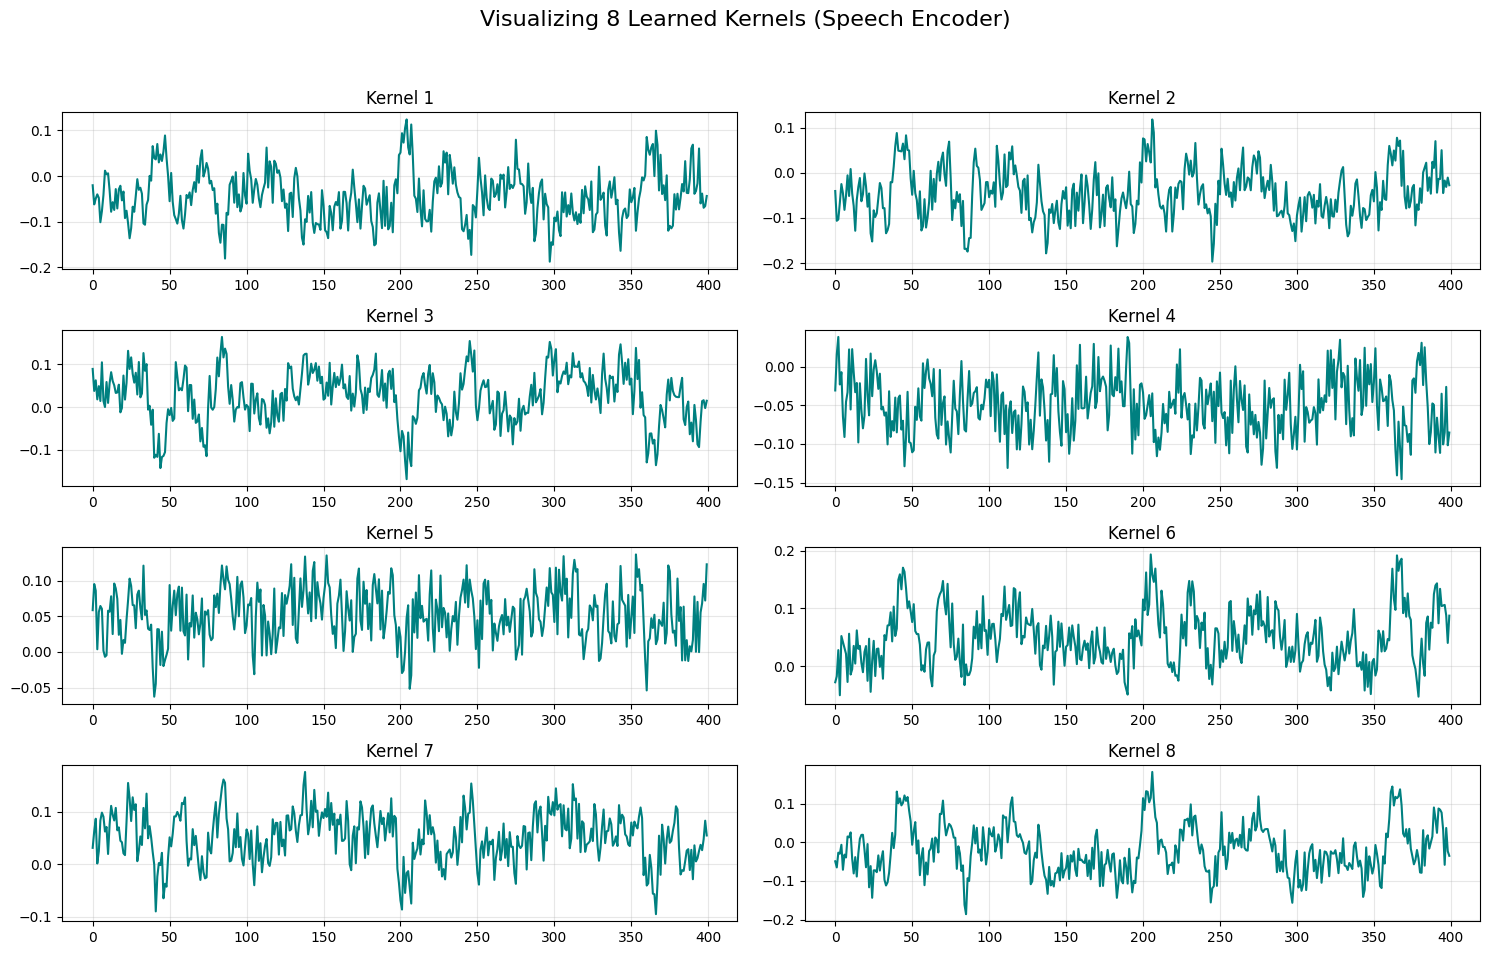

In [21]:
def plot_learned_kernels(model):
    # 1. Extract the weights from the conv layer
    # Shape: (out_channels=8, in_channels=1, kernel_size=400)
    kernels = model.conv.weight.detach().cpu().numpy()
    
    plt.figure(figsize=(15, 10))
    plt.suptitle("Visualizing 8 Learned Kernels (Speech Encoder)", fontsize=16)

    for i in range(8):
        # 2. Select the i-th kernel
        # We index [i, 0, :] because in_channels is 1
        kernel_values = kernels[i, 0, :]
        
        plt.subplot(4, 2, i + 1)
        plt.plot(kernel_values, color='teal')
        plt.title(f"Kernel {i+1}")
        plt.grid(True, alpha=0.3)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    plt.show()

# Assuming your trained model is named 'model'
# Use the model from your most recent training run
plot_learned_kernels(model)